$$\frac{\partial A}{\partial z} = -\frac{\alpha}{2} A - \frac{i}{2} \beta_2 \frac{\partial^2 A}{\partial^2 T} + i \gamma |A|^2 A$$

$$\begin{align}
\hat N &= i \gamma |A|^2 \\
\hat D &= -\frac{\alpha}{2} - \frac{i}{2} \beta_2 \frac{\partial^2}{\partial^2 T} \\
\hat D(\omega) &= -\frac{\alpha}{2} + \frac{i}{2} \beta_2 \omega^2 \\
\end{align}$$

$$T = t-\frac{z}{v_g}$$

In [1]:
%load_ext autoreload
%autoreload 2
# %aimport NLSE

In [2]:
import numpy as np

def D_freq(f: np.ndarray, beta2) -> np.ndarray:
    '''
    f: Frequency corresponding to A (cycles/sec)
    '''
    omega = 2 * np.pi * f
    return 1j * beta2 / 2 * omega ** 2

def apply_D(A, h, dt, **kwargs) -> np.ndarray:
    '''
    A: field amplitude (in the time domain)
    h: step length in z
    dt: distance between points in t
    '''
    A0_f = np.fft.fft(A)
    f = np.fft.fftfreq(A.size, d=dt)
    D = D_freq(f, **kwargs)

    A1_f = np.exp( h * D / 2 ) * A0_f
    return np.fft.ifft(A1_f)

def N_t(A: np.ndarray, gamma) -> np.ndarray:
    '''
    A: field amplitude (in the time domain)
    '''
    N = 1j * gamma * np.abs(A) ** 2
    return N

# Getting constants figured out

In [3]:
beta2 = -4.20056799728266e-27 # s^2 m^-1

A_eff = 50e-12 # in m^2
n_2 = 3.2e-20 # m^2 W^-1
lambda_0 = 1.55e-6
gamma = 2 * np.pi * n_2 / (lambda_0 * A_eff)

N = 2
T_0 = 1e-12
FWHM = 1.76 * T_0
L_D = T_0 ** 2 / np.abs( beta2 )
P_0 = N ** 2 / ( L_D * gamma )
print(f'This simulation is happening for\n\tFWHM: {FWHM}s\n\tPower: {P_0} W\n\tN: {N}')

L_NL = 1 / ( gamma * P_0 )
assert np.isclose(L_D / L_NL, N ** 2), 'N is not self consistent!'

This simulation is happening for
	FWHM: 1.76e-12s
	Power: 6.476492492936225 W
	N: 2


# Simulation Loop

In [4]:
from tqdm import tqdm
# from NLSE import split_step

t = np.linspace(-80e-12, 80e-12, 4096)
A_0 = np.sqrt(P_0) / np.cosh(t / T_0)

n_integral_iterations = 10
Z = np.linspace(0, 10*np.pi/2 * L_D, 4096)
print(f'This travels to:\n\tZ: {Z[-1]:.2f} m\n\tXi: {Z[-1] / L_D}')
dZ = Z[1] - Z[0]

A = np.zeros((Z.size, A_0.size), dtype=complex)
A[0] = A_0

'''
So we find N(z+h) by running through the calculation assuming N(z+h) = N(z) to find A(z+h) to plug back in to find N(z+h)

THIS CODE DOES NOT DO:
exp(D * h / 2)[ exp(N * h / 2)exp(D * h / 2)A(z, T) exp(N * h / 2)exp(D * h / 2)A(z + h, T) ]

It does
exp(D * h / 2) exp(( N(A(z)) + N(A(z+h)) ) * h / 2) exp(D * h / 2) A(z, T)

N_z = N(A(z))
N_zh = N(A(z+h))
DA_z = exp(D * h / 2) A(z, T)
A_mid = exp(( N(A(z)) + N(A(z+h)) ) * h / 2) exp(D * h / 2) A(z, T)
'''
for ind, A_z in tqdm(enumerate(A[:-1])):
    A_zh = np.copy(A_z)
    N_z = N_t(A_z, gamma)
    DA_z = apply_D(A_z, dZ, t[1] - t[0], beta2=beta2)
    
    for _ in range(n_integral_iterations):
        N_zh = N_t(A_zh, gamma)
        
        A_mid = np.exp( dZ * ( N_z + N_zh ) / 2 ) * DA_z
        A_zh = apply_D(A_mid, dZ, t[1] - t[0], beta2=beta2)
    A[ind + 1] = A_zh

This travels to:
	Z: 3739.49 m
	Xi: 15.707963267948966


4095it [00:06, 594.85it/s]


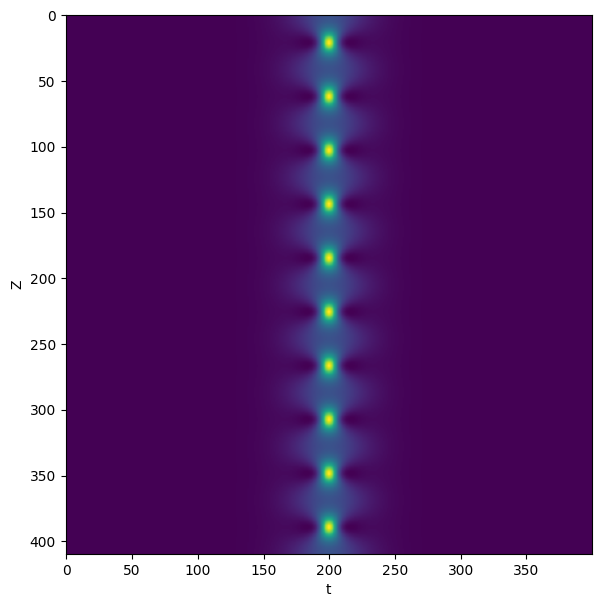

In [5]:
import matplotlib.pyplot as plt

mid = A[0].size // 2
plt.figure(figsize=(7,7))
plt.imshow(np.abs(A[::10,mid-200:mid+200])**2)
plt.ylabel('Z')
plt.xlabel('t')
plt.show()

(-5e-12, 5e-12)

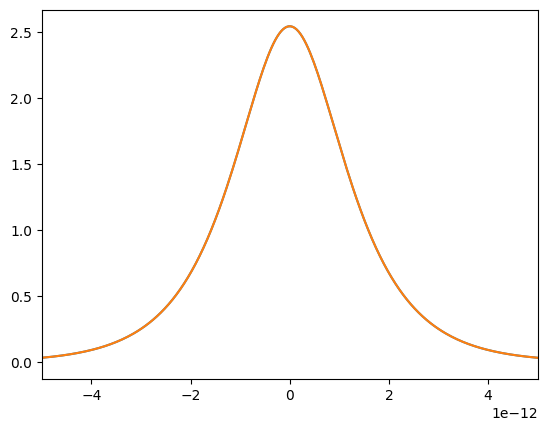

In [6]:
plt.plot(t, np.abs(A[0]))
plt.plot(t, np.abs(A_0))
plt.xlim(-5e-12,5e-12)

In [8]:
from NLSE import split_step_old

t = np.linspace(-80e-12, 80e-12, 4096)
A_0 = np.sqrt(P_0) / np.cosh(t / T_0)

n_integral_iterations = 10
Z = np.linspace(0, 10*np.pi/2 * L_D, 4096)
print(f'This travels to:\n\tZ: {Z[-1]:.2f} m\n\tXi: {Z[-1] / L_D}')
dZ = Z[1] - Z[0]

# A = np.zeros((Z.size, A_0.size), dtype=complex)
# A[0] = A_0

A = split_step_old(A_0, t, Z, gamma=gamma, beta2=beta2)

This travels to:
	Z: 3739.49 m
	Xi: 15.707963267948966


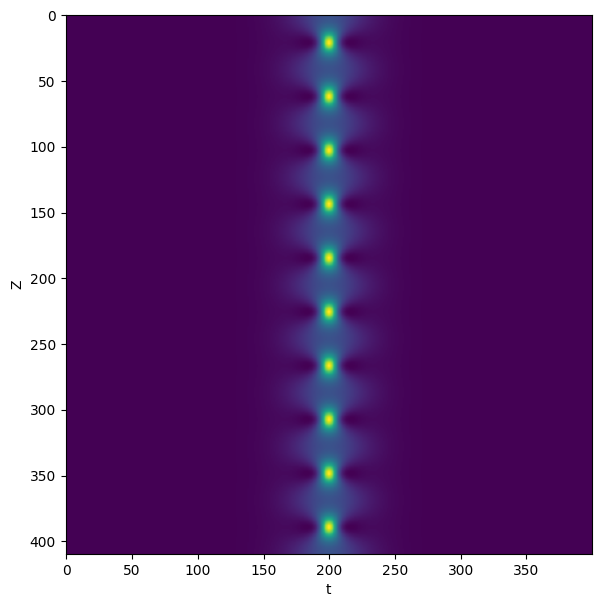

In [9]:
import matplotlib.pyplot as plt

mid = A[0].size // 2
plt.figure(figsize=(7,7))
plt.imshow(np.abs(A[::10,mid-200:mid+200])**2)
plt.ylabel('Z')
plt.xlabel('t')
plt.show()

This travels to:
	Z: 3739.49 m
	Xi: 15.707963267948966


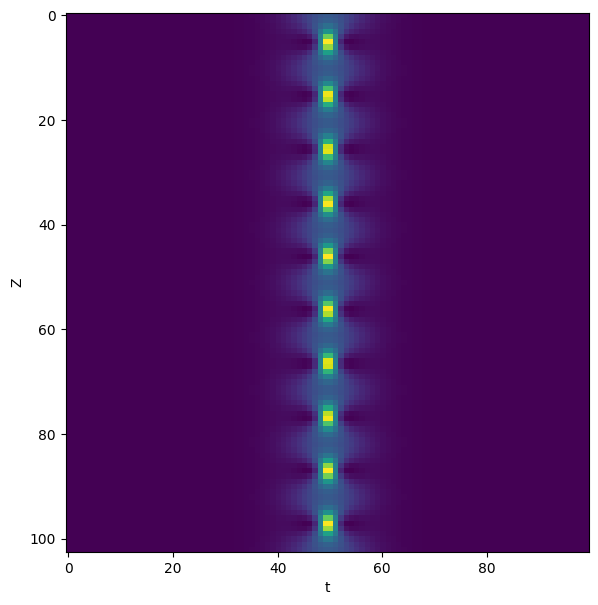

In [10]:
from NLSE import split_step

def nl_operator(A):
    return 1j * gamma * np.abs(A) ** 2

def diff_operator(omega):
    return 1j * beta2 / 2 * omega ** 2

t = np.linspace(-80e-12, 80e-12, 1024)
A_0 = np.sqrt(P_0) / np.cosh(t / T_0)

n_integral_iterations = 10
Z = np.linspace(0, 10*np.pi/2 * L_D, 1024)
print(f'This travels to:\n\tZ: {Z[-1]:.2f} m\n\tXi: {Z[-1] / L_D}')
dZ = Z[1] - Z[0]

# A = np.zeros((Z.size, A_0.size), dtype=complex)
# A[0] = A_0

# A_new = split_step(A_0, t, Z, gamma=gamma, beta2=beta2)
A_new = split_step(A_0, t, Z, diff_operator, nl_operator)

mid = A_new[0].size // 2
plt.figure(figsize=(7,7))
plt.imshow(np.abs(A_new[::10,mid-50:mid+50])**2)
plt.ylabel('Z')
plt.xlabel('t')
plt.show()

In [11]:
%timeit split_step(A_0, t, Z, diff_operator, nl_operator)
%timeit split_step_old(A_0, t, Z, gamma=gamma, beta2=beta2)

322 ms ± 2.71 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)
535 ms ± 4.39 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)
